# Explicabilidad en modelos de Aprendizaje Profundo Convolucional.

## 1. Grad-CAM?

*Grad-CAM* es una técnica de visualización usada para explicar las decisiones tomadas por modelos de redes neuronales convolucionales (. Permite identificar qué regiones de una imagen influyen más en la predicción de una clase específica.


### ¿Cómo funciona Grad-CAM?

Dado un modelo de redes convolucionales y una imagen de entrada, Grad-CAM realiza lo siguiente:

1. Selecciona una capa convolucional profunda $\mathbf{A}^c$, usualmente la última capa convolucional.

2. Calcula los gradientes de los logits (predicción antes de softmax) de cada clase $y^k$  con respecto a cada mapa de activación $A^c$:

   $$
   \frac{\partial y^k}{\partial A^c}
   $$

3. Promedia espacialmente esos gradientes para obtener pesos $\alpha_k^c$:

   $$
   \alpha_c^k = \frac{1}{Z} \sum_{i,j} \frac{\partial y^k}{\partial A_{i,j}^c}
   $$

   donde $Z$ es el número de elementos en el mapa (ancho × alto).
4. Construye un mapa ponderado de activación:

   $$
   L_{\text{Grad-CAM}}^k = \text{ReLU} \left( \sum_c \alpha_c^k A^c \right)
   $$
5. El resultado es un mapa de calor que muestra qué regiones de la imagen contribuyeron en mayor medida a la clase objetivo.


In [ ]:
!pip install torchinfo
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 110.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=b2b5a5b6df34fdd9b66d552ada30ffd120ebc1f5c55d12cf9038886d4bde92e2
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from torchvision.transforms import ToTensor

import os, shutil

import numpy as np
import cv2

import zipfile
import torchinfo
from torchinfo import summary

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, \
    deprocess_image, \
    preprocess_image

## 1. Cargar y preprocesar imagen para entrenar un modelo de aprendizaje profundo con redes convolucionales.

In [ ]:
!pip install jovian --upgrade --quiet
!pip install opendatasets --upgrade --quiet
import opendatasets as od
od.download('https://www.kaggle.com/c/dogs-vs-cats')
# julingilgonzlez
# 5fdd75b1cda4de2f224f50f539c4210e

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 4.3 MB/s eta 0:00:00
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: julingilgonzlez
Your Kaggle Key: ··········


100%|██████████| 812M/812M [00:03<00:00, 220MB/s]



Extracting archive ./dogs-vs-cats/dogs-vs-cats.zip to ./dogs-vs-cats


In [ ]:
# Se decomprime la carpeta zip
!unzip /content/dogs-vs-cats/train.zip

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: train/dog.5499.jpg      
  inflating: train/dog.55.jpg        
  inflating: train/dog.550.jpg       
  inflating: train/dog.5500.jpg      
  inflating: train/dog.5501.jpg      
  inflating: train/dog.5502.jpg      
  inflating: train/dog.5503.jpg      
  inflating: train/dog.5504.jpg      
  inflating: train/dog.5505.jpg      
  inflating: train/dog.5506.jpg      
  inflating: train/dog.5507.jpg      
  inflating: train/dog.5508.jpg      
  inflating: train/dog.5509.jpg      
  inflating: train/dog.551.jpg       
  inflating: train/dog.5510.jpg      
  inflating: train/dog.5511.jpg      
  inflating: train/dog.5512.jpg      
  inflating: train/dog.5513.jpg      
  inflating: train/dog.5514.jpg      
  inflating: train/dog.5515.jpg      
  inflating: train/dog.5516.jpg      
  inflating: train/dog.5517.jpg      
  inflating: train/dog.5518.jpg      
  inflating: train/dog.5519.jpg      
  inflating: train/dog.552.

In [ ]:
original_dataset_dir = '/content/train'
base_dir = '/content'
# Se crea un directorio para el entrenamiento
train_dir = os.path.join(base_dir, 'train_dir')
os.mkdir(train_dir)

# Se crea un directorio para el test
test_dir = os.path.join(base_dir, 'test_dir')
os.mkdir(test_dir)

# Dentro de la carpeta de entrenamiento se geneta una carpeta para cada clase.
train_cats_dir = os.path.join(train_dir, 'cats')
os.mkdir(train_cats_dir)
train_dogs_dir = os.path.join(train_dir, 'dogs')
os.mkdir(train_dogs_dir)

# Dentro de la carpeta de prueba se geneta una carpeta para cada clase.
test_cats_dir = os.path.join(test_dir, 'cats')
os.mkdir(test_cats_dir)
test_dogs_dir = os.path.join(test_dir, 'dogs')
os.mkdir(test_dogs_dir)

In [ ]:
# Se copian 7000 imágenes de gatos en la carpeta de entrenamiento
fnames = ['cat.{}.jpg'.format(i) for i in range(7000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_cats_dir, fname)
    shutil.copyfile(src, dst)

In [ ]:
# Se copian 7000 imágenes de perros en la carpeta de entrenamiento
fnames = ['dog.{}.jpg'.format(i) for i in range(7000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_dogs_dir, fname)
    shutil.copyfile(src, dst)

In [ ]:
# Se copian 3000 imágenes de gatos en la carpeta de prueba
fnames = ['cat.{}.jpg'.format(i) for i in range(7000, 10000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(test_cats_dir, fname)
    shutil.copyfile(src, dst)

In [ ]:
# Se copian 3000 imágenes de perros en la carpeta de prueba
fnames = ['dog.{}.jpg'.format(i) for i in range(7000, 10000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(test_dogs_dir, fname)
    shutil.copyfile(src, dst)

In [ ]:
# Se fija el tamaño de las imágenes.
IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT)

# Se escribe una rutina para transformar las imágenes. Se aplica data augmentation
# para minimizar el impacto del sobreajuste
data_transform = transforms.Compose([
    # Se hace un reescalado de las imágenes dado que tienen tamaños diferentes
    transforms.Resize(size=IMAGE_SIZE),
    # Se hace DataAugmentation al generar imágenes sintéticas que corresponden a
    # versiones rotadas de las imágenes originales.
    transforms.RandomRotation(degrees=45),
    # DataAugmentation: Se realiza un flip horixontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Se convierten las imágenes a tensores
    transforms.ToTensor()
])

# No se suele realizar DataAugmentation en el conjunto de test
data_transform_test = transforms.Compose([
    transforms.Resize(size=IMAGE_SIZE),
    transforms.ToTensor()
])


In [ ]:
# Se fija el tamaño de las imágenes.
IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT)

# Se escribe una rutina para transformar las imágenes
data_transform = transforms.Compose([
    # Se hace un reescalado de las imágenes dado que tienen tamaños diferentes
    transforms.Resize(size=IMAGE_SIZE),
    # Se hace DataAugmentation al generar imágenes sintéticas que corresponden a
    # versiones rotadas de las imágenes originales.
    transforms.RandomRotation(degrees=45),
    # DataAugmentation: Se realiza un flip horixontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Se convierten las imágenes a tensores
    transforms.ToTensor()
])

# No se suele realizar DataAugmentation en el conjunto de test
data_transform_test = transforms.Compose([
    transforms.Resize(size=IMAGE_SIZE),
    transforms.ToTensor()
])

In [ ]:
# Se crean los conuntos de train y test.
train_data = datasets.ImageFolder(root=train_dir, # Se pasa la dirección donde
                                  # se gurdan las imágenes de train.
                                  transform=data_transform,
                                  target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform_test)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 14000
    Root location: /content/train_dir
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomRotation(degrees=[-45.0, 45.0], interpolation=nearest, expand=False, fill=0)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 6000
    Root location: /content/test_dir
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [ ]:
# Se rectifican las etiquetas
class_names = train_data.classes
print("Class names: ",class_names)


class_dict = train_data.class_to_idx
print("Class names as a dict: ",class_dict)

# Se verifican las longitudes
print("The lengths of the training and test sets: ", len(train_data), len(test_data))

Class names:  ['cats', 'dogs']
Class names as a dict:  {'cats': 0, 'dogs': 1}
The lengths of the training and test sets:  14000 6000


In [ ]:
# Se crean los dataloaders
NUM_WORKERS = os.cpu_count()

# DataLoaders
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32,
                              num_workers=NUM_WORKERS,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,
                             num_workers=NUM_WORKERS,
                             shuffle=True)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c24363d2a20>,
 <torch.utils.data.dataloader.DataLoader at 0x7c27a2d625d0>)

## 2. Entrenar el modelo convolucional.

In [ ]:
# Se verifica la disponibilidad de la GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)

cuda:0


In [ ]:
# Se carga el modelo pre-entrenado.
model = models.vgg16(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False

print(model)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 164MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# Para visualizar el modelo base
summary(model, input_size=[1, 3, IMAGE_WIDTH ,IMAGE_HEIGHT])

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 1000]                 --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         (1,792)
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         (36,928)
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        (73,856)
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        (147,584)
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]    

In [ ]:
# Se modifica la última capa para que tenga 2 neuronas, una por clase
model.classifier[6] = nn.Linear(in_features=4096, out_features=2)
# Para GradCam la última capa debe tener activación lineal.
model = model.to(device)

# Función de costo
loss_fn = nn.CrossEntropyLoss()
epochs = 10

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [ ]:
summary(model, input_size=[1, 3, IMAGE_WIDTH ,IMAGE_HEIGHT])

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 2]                    --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         (1,792)
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         (36,928)
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        (73,856)
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        (147,584)
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]    

In [ ]:
# The optimization loop.

loss_tr = []
loss_te = []
for epoch in range(epochs):
  for x, y in train_dataloader:
    # The variable should be sent to the GPU
    x = x.to(device)
    y = y.to(device)
    # Make predictions
    model.train()
    y_pred = model(x)

    y = y.to(torch.long)
    # print(y,y_pred)
    # Compute the loss of current predictions
    loss = loss_fn(y_pred, y)
    # Clean the gradients
    optimizer.zero_grad()
    # Perform backpropagation
    loss.backward()
    # update weights
    optimizer.step()
    # Storing the training and test losses
    loss_tr.append(loss.item())
    loss_test = 0
  # since we're not training, we don't need to calculate the gradients for our outputs
  with torch.no_grad():
    for data in test_dataloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        labels = labels.to(torch.long)
        # calculate outputs by running images through the network
        outputs = model(images)
        loss_test += loss_fn(outputs, labels).item() * labels.size(0)

  loss_te.append(loss_test/len(test_dataloader.dataset))
  print("epoch {} loss: {:.4f} test_loss: {:.4f}".format(epoch + 1,loss.item(),loss_test/len(test_dataloader.dataset)))

epoch 1 loss: 0.2202 test_loss: 0.1698
epoch 2 loss: 0.1737 test_loss: 0.1560
epoch 3 loss: 0.2561 test_loss: 0.1429
epoch 4 loss: 0.5185 test_loss: 0.1377
epoch 5 loss: 0.0912 test_loss: 0.1368
epoch 6 loss: 0.3388 test_loss: 0.1384
epoch 7 loss: 0.2576 test_loss: 0.1265
epoch 8 loss: 0.1711 test_loss: 0.1273
epoch 9 loss: 0.4214 test_loss: 0.1242
epoch 10 loss: 0.0759 test_loss: 0.1262


## 3. Calcular Grad-CAM

Se emplea la librería `pytorch-grad-cam`

In [ ]:
# Obtener una imagen del set de validación
sample_image, label = next(iter(test_dataloader))
id = 19 # algún número entre 0 y bath_size - 1
sample = sample_image[id:id+1]  # solo una imagen
sample = sample.to(device)

In [ ]:
# Se predice la clase de la imagen elegida.
model.eval()
with torch.no_grad():
    outputs = model(sample)
    _, predicted = torch.max(outputs.data, 1)
    predicted_class_index = predicted.item()
    predicted_class_name = class_names[predicted_class_index]
    print(f"Predicted class index: {predicted_class_index}")
    print(f"Predicted class name: {predicted_class_name}")


Predicted class index: 0
Predicted class name: cats


In [ ]:
# GradCam necesita calcular gradientes, así, es necesario que tdos los parámetros
# Tengan el parámetro "requires_grad" activo.
for param in model.parameters():
    param.requires_grad = True

In [ ]:
# EL GradCam se hace con respecto a cada salida, se elige la salida según la
# predicción del modelo. Si es un gato quiero el GradCam de la clase gato, no perro
targets = [ClassifierOutputTarget(predicted_class_index)]
#targets = [ClassifierOutputTarget(0)]

# Se elige la capa convolucional con respecto a la cual se hará el GradCam. Se
# suele elegir la última capa convolucional.
metric_targets = [model.features[29]]


# Se calcula y visualiza el GradCam.
with GradCAM(model=model, target_layers=metric_targets) as cam:
  attributions = cam(input_tensor=sample, targets=targets)#

sample_np = sample.squeeze(0).permute(1, 2, 0).cpu().numpy()

cam_image = show_cam_on_image(sample_np, attributions[0, :], use_rgb=True)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

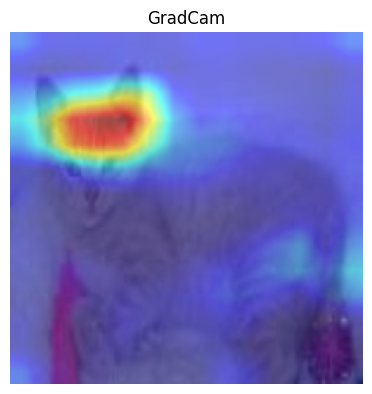

In [ ]:
plt.figure(figsize=(10, 5))

# Mostrar imagen con GradCam
plt.subplot(1, 2, 1)
plt.imshow(cam_image)
plt.title("GradCam")
plt.axis("off")

## 2. GradCam++

Grad-CAM++ es una mejora de Grad-CAM que permite: mejorar localización espacial de las regiones relevantes; visualizar contribuciones de múltiples regiones dispersas y aplicarse a tareas con objetos pequeños o múltiples instancias.

Grad-CAM tradicional utiliza un único peso global:

$$
\alpha_k^c = \frac{1}{Z} \sum_{i,j} \frac{\partial y^c}{\partial A_{i,j}^k}
$$

Este promedio no distingue contribuciones individuales por píxel, lo que puede ocultar detalles importantes si hay activaciones dispersas o sutiles. Grad-CAM++ introduce una forma más fina de pesos, considerando gradientes de segundo orden.

Sea que $\mathbf A^c$ es el mapa de activación del canal $c$ en una capa convolucional, y $y^K$ es el score de la clase.

### 1. Gradientes parciales de primer y segundo orden:

$$
g_{i,j,c} = \frac{\partial y^k}{\partial A_{i,j}^c}, \quad g^2_{i,j,c} = \frac{\partial^2 y^k}{\partial (A_{i,j}^c)^2}
$$

### 2. Cálculo de los coeficientes $\alpha_{i,j}^k$:

$$
\alpha_{i,j}^c = \frac{g_{i,j,c}^2}{2g_{i,j,c}^2 + \sum_{i,j} A_{i,j}^c g^2_{i,j,c}}
$$

### 3. Ponderación:

$$
w_c^k = \sum_{i,j} \alpha_{i,j}^c \cdot \text{ReLU}(g_{i,j,c})
$$

### 4. Mapa Grad-CAM++:

$$
L_{\text{Grad-CAM++}}^k = \text{ReLU}\left( \sum_c w_c^k A^c \right)
$$



In [ ]:
# EL GradCam se hace con respecto a cada salida, se elige la salida según la
# predicción del modelo. Si es un gato quiero el GradCam de la clase gato, no perro
targets = [ClassifierOutputTarget(predicted_class_index)]

# Se elige la capa convolucional con respecto a la cual se hará el GradCam. Se
# suele elegir la última capa convolucional.
metric_targets = [model.features[29]]


# Se calcula y visualiza el GradCam.
with GradCAMPlusPlus(model=model, target_layers=metric_targets) as cam:
  attributions = cam(input_tensor=sample, targets=targets)#

sample_np = sample.squeeze(0).permute(1, 2, 0).cpu().numpy()

cam_image = show_cam_on_image(sample_np, attributions[0, :], use_rgb=True)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

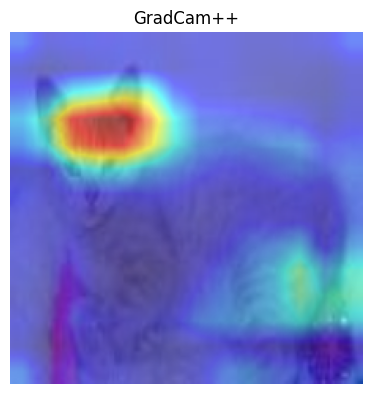

In [ ]:
plt.figure(figsize=(10, 5))

# Mostrar imagen con GradCam
plt.subplot(1, 2, 1)
plt.imshow(cam_image)
plt.title("GradCam++")
plt.axis("off")